In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.tree import export_text
from sklearn.tree import _tree
from tqdm.notebook import tqdm # used to show progress bar while hill-climbing


import matplotlib.pyplot as plt

random_state=42

## Data exploration/preprocessing

### Load dataset, convert target to numerical type

Load dataset from .csv file, drop empty columns. And divide into X, y.
The target column is `diagnosis`, its values are categorical with 2 unique values:
- `M`: malignant (**cancerous**) tumors
- `B`: benign (**non-cancerous**) tumors

In [2]:
# Load the dataset
columns = ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']
breast_cancer = pd.read_csv('data_wisconsin.csv', index_col='id')
breast_cancer = breast_cancer[columns] # get rid of unnamed column
breast_cancer
X = breast_cancer.drop(columns='diagnosis')
y = breast_cancer['diagnosis']
display(y.unique())
y = y.replace({'M': 1, 'B': 0})
y = y.rename('has_cancer')

array(['M', 'B'], dtype=object)

### Check null values, useless features

Dataset has no null values

In [3]:
X.isna().sum().sum()

0

I will check the correlation between X and y. <br>
Freatures `symmetry_se`, `texture_se`, `fractal_dimension_mean`, `smoothness_se` aren't correlated with the target feature, so I'll drop them to reduce the dimensionality of X. <br>
Even though RF is robust towards features that don't correlate with target and basically ignores them, dropping columns that have correlation of almost 0 will make the classification simpler.

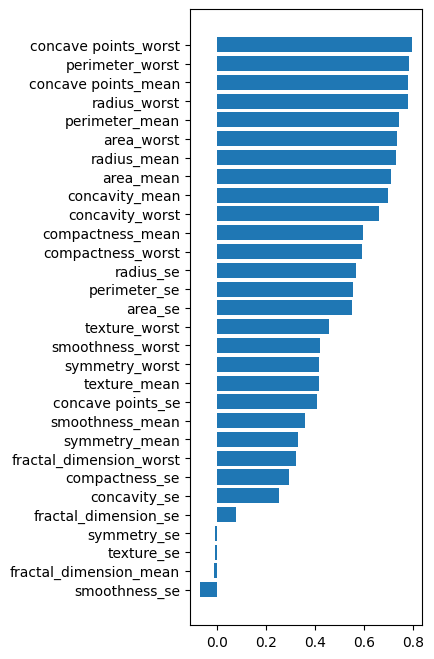

In [4]:
corr = X.corrwith(y)
corr.sort_values(inplace=True)

fig, ax = plt.subplots(figsize=(3, 8))
plt.barh(y=corr.index, width=corr)  # Corrected order of arguments
columns_to_drop = ['symmetry_se', 'texture_se', 'fractal_dimension_mean', 'smoothness_se']
X.drop(columns=columns_to_drop, inplace=True)

Split dataset into train, test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

## Random forest training

In [6]:
# Step 1: Train a Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Rule extraction
Class that represents a single rule, to make the evaluation of a single row easier.

In [7]:
class Rule:
    """
    Rule ≈ (c_1(y) and c_2(y) and ... c_n(y)) \n where `n` in number of supplied conditions \n and `y` is vector
    """
    def __init__(self, cl, conditions=[], str=''):
        self._conditions = conditions
        self._class = cl
        self._str = str
    def __str__(self):
        return self._str
    def match(self, y):
        """
        @returns 
        """
        for condition in self._conditions:
            if not condition(y):
                return False
        return True

Define function that extracts rules from a decision tree

In [8]:
def get_rules(tree, feature_names, class_names):
    """https://mljar.com/blog/extract-rules-decision-tree/"""
    # Extract the internal tree structure
    tree_ = tree.tree_

    # Create a list of feature names, replacing undefined features
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    # Initialize empty lists to store paths through the decision tree
    paths = []
    path = []
    condition = []
    conditions = []
    all_classes = []
    
    # Define a recursive function to traverse the decision tree nodes and build paths
    def recurse(node, path, paths, condition, conditions, all_classes):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            # If the current node has a feature, add conditions to the path
            name = feature_name[node]
            feature_index = tree_.feature[node]
            threshold = tree_.threshold[node]
            c1, c2 = list(condition), list(condition) # deep copy
            p1, p2 = list(path), list(path) # deep copy

            c1.append(lambda tmp: (tmp[name] <= threshold))
            
            c2.append(lambda tmp: (tmp[name] > threshold))
            
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            # Recursively traverse the left child node
            recurse(tree_.children_left[node], p1, paths, c1, conditions, all_classes)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            # Recursively traverse the right child node
            recurse(tree_.children_right[node], p2, paths, c2, conditions, all_classes)
        else:
            # If the node is a leaf, add the node's value and the number of samples to the path
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            # Add the path to the list of paths
            paths += [path]
            conditions += [condition]
            all_classes += [np.argmax(tree_.value[node])] # add class with highest prob
            
    # Start the recursion from the root of the decision tree
    recurse(0, path, paths, condition, conditions, all_classes)


    # Initialize a list to store the human-readable rules
    rules = []

    # Iterate through the sorted paths to construct human-readable rules
    for path in paths:
        rule = "IF "

        # Construct a rule string with conditions based on the path
        for p in path[:-1]:
            if rule != "IF ":
                rule += " & "
            rule += str(p)

        rule += " THEN "
        
        class_name = "undefined!"
        
        # If class names are provided, add the predicted class and its probability to the rule
        if class_names is None:
            rule += "response: " + str(np.round(path[-1][0][0][0], 3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            class_name = class_names[l]
            rule += f'class {class_name}'
        rules += [rule]

    res = []
    
    # Return the list of rules
    for i in range(len(paths)):
        res += [Rule(cl=all_classes[i], conditions=conditions[i], str=rules[i])]
    return res

In [9]:
rules = []
for est in rf_classifier.estimators_:
    rules += get_rules(est, X_test.columns, ['M', 'B'])
original_rule_count = len(rules)

## Hill Climbing
### Calculate the coverage matrix

In [10]:
def getCoverage(rules:list, data):
    w = len(rules)
    h = data.shape[0]
    RsCoverage=np.zeros((h, w))
    RsCoverage = pd.DataFrame(RsCoverage, index=data.index) * np.NaN
    for idx, row in data.iterrows():
        for r in range(w):
            if rules[r].match(row):
                RsCoverage.loc[idx, r] = rules[r]._class
    return RsCoverage

In [11]:
RsCoverage = getCoverage(rules, X_train)
RsCoverage

,0,1,2,3,4,5,6,7,8,9,...,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678
id,,,,,,,,,,,,,,,,,,,,,
869931,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
865468,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
906564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
875878,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
922576,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859711,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
863031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8910721,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Score extracted rules

#### RScore

In [12]:
def ruleScore(coverage, target):
    """https://www.researchgate.net/publication/272742180_Rule_Extraction_from_Random_Forest_the_RFHC_Methods"""
    rule_scores = []
    for col in coverage:
        same_class = coverage[col] == target
        cc = same_class.sum()
        ic = (~same_class).sum()
        k = 4 # constant from the source paper
        score = (cc - ic) / (cc + ic)
        score += cc / (ic + k)
        # print(f'cc: {cc}, ic: {ic}, score: {score}')
        rule_scores.append(score)  
    return np.array(rule_scores)

Normalize scores so that `np.random.choice` can interpret them as a probability distribution

In [13]:
scores = ruleScore(RsCoverage, y_train)
scores += 1.
scores /= np.sum(scores)
assert(np.isclose(np.sum(scores), 1.)) # sanity check
df_rules = pd.DataFrame(data={'rule':rules, 'prob': scores})
best_rule_idx = np.argmax(scores)
best_rule = df_rules.iloc[[best_rule_idx]]
display(df_rules)
display(best_rule)

,rule,prob
0,IF (concavity_mean <= 0.093) & (concave points...,0.004232
1,IF (concavity_mean <= 0.093) & (concave points...,0.000022
2,IF (concavity_mean <= 0.093) & (concave points...,0.000938
3,IF (concavity_mean <= 0.093) & (concave points...,0.000089
4,IF (concavity_mean <= 0.093) & (concave points...,0.000066
...,...,...
1674,IF (radius_mean > 14.98) & (texture_mean <= 16...,0.000155
1675,IF (radius_mean > 14.98) & (texture_mean <= 16...,0.000111
1676,IF (radius_mean > 14.98) & (texture_mean > 16....,0.000044
1677,IF (radius_mean > 14.98) & (texture_mean > 16....,0.000044


,rule,prob
821,IF (perimeter_mean <= 99.02) & (radius_worst <...,0.007157


#### Ruleset accuracy

In [14]:
def ruleset_accuracy(rules, data, target):
    coverage = getCoverage(list(rules), data)
    # majority vote, just like in RF
    pred = coverage.mode(numeric_only=True, axis=1)[0]
    n = len(target)
    n_correct = (np.array(target) == np.array(pred)).sum()
    return n_correct / n

### Find best rule subset
I'll use the RScore that had beed normalized to act as a probability distribution and supply it into the `np.random.choice` function. <br>
This ensures that rules with higher RScore get picked with higher probability. <br>

In [15]:
imp_rules = best_rules = best_rule
best_rules_acc = improved_rules_acc = 0
max_iteration = 300
best_score_iter = 0

for i in tqdm(range(max_iteration)):
    np.random.seed(42 + i) # get different random number each iteration (but still achieve same results everytime notebook is ran)
    # pick new rule
    imp_rules_idx = np.random.choice(df_rules.index, size = 1, p=df_rules.prob)
    imp_rules_old = imp_rules.copy()
    imp_rules = pd.concat([imp_rules, df_rules.loc[imp_rules_idx]])
    
    imp_rules_acc = ruleset_accuracy(imp_rules.rule, X_train, y_train)
    imp_rules_old_acc = ruleset_accuracy(imp_rules_old.rule, X_train, y_train)
    print(f'current best score: {best_rules_acc} (from iteration {best_score_iter})', end='\r')
    # if new rule doesn't make ruleset better, revert back
    if (imp_rules_acc <= imp_rules_old_acc):
        imp_rules = imp_rules_old
    # take note of the best score
    if (imp_rules_acc > best_rules_acc):
        best_score_iter = i
        best_rules = imp_rules
        best_rules_acc = imp_rules_acc
best_rules_acc

  0%|          | 0/300 [00:00<?, ?it/s]

0.992462311557789

## Result
The final ruleset has almost the same accuracy as the original RF whilst being much simpler and therefore more effective. <br>
We've managed to reduce the number of rules by more than 90%. <br>
This might be beneficial for easy interpretation of the rules. 

In [16]:
best_rules

,rule,prob
821,IF (perimeter_mean <= 99.02) & (radius_worst <...,0.007157
621,IF (compactness_mean > 0.102) & (perimeter_mea...,0.000312
178,IF (perimeter_worst > 106.05) & (smoothness_wo...,0.000222
1391,IF (concave points_worst <= 0.142) & (radius_s...,0.004808
1660,IF (concavity_mean > 0.082) & (concave points_...,0.003049
1312,IF (radius_mean <= 15.11) & (concave points_wo...,0.007052
26,IF (radius_worst > 16.795) & (texture_worst > ...,0.003020
695,IF (concavity_worst <= 0.262) & (perimeter_wor...,0.005075
138,IF (area_worst > 865.65) & (fractal_dimension_...,0.002902
605,IF (concavity_mean > 0.093) & (concave points_...,0.003049


In [17]:
hc_acc = ruleset_accuracy(best_rules.rule, X_test, y_test)
print(f'RF + HC test accuracy: {hc_acc*100:.2f}% ({len(best_rules.rule)} rules)')

RF + HC test accuracy: 95.32% (17 rules)


In [18]:
rf_acc = accuracy_score(rf_classifier.predict(X_test), y_test)
print(f'RF test accuracy: {rf_acc*100:.2f}% ({original_rule_count} rules)')

RF test accuracy: 97.66% (1679 rules)


In [19]:
fname = 'final_ruleset.txt'
with open(fname, 'w') as f:
    tmp = ''
    for rule in best_rules.rule:
        tmp += str(rule) + '\n'
    f.write(tmp)
print(f'Successfully written rules into {fname}')

Successfully written rules into final_ruleset.txt
